In [1]:
#https://huggingface.co/docs/transformers/main_classes/pipelines#transformers.SummarizationPipeline

from transformers import pipeline
import os

In [2]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
summarizer = pipeline("summarization")
#sshleifer/distilbart-cnn-12-6 (https://huggingface.co/sshleifer/distilbart-cnn-12-6)



No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 (https://huggingface.co/sshleifer/distilbart-cnn-12-6)


In [4]:
#Electronics Dataset:

import numpy as np
import pandas as pd
fileElectr='amazon_reviews_us_Electronics_v1_00.tsv'
df=pd.read_csv(fileElectr, sep="\t", header=0, on_bad_lines='skip')
df=df.dropna(subset=['review_headline', 'review_body', 'star_rating'])

In [5]:
df_sample=df.sample(10, replace=False, random_state=155) #take a sample of 10 samples

In [6]:
df_sample.reset_index(inplace=True)
df_sample

,index,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,1187914,US,13315115,RF5VUB41XW7H9,B00JZBE97U,327246460,MegaWatt (™) S-350-12 30 Amp 9.5-15 Volts Adju...,Electronics,5,1,2,N,Y,Five Stars,"this one works, and it came with a power cord.",2014-08-17
1,2392679,US,51236780,R5JMOOJE5RNL5,B0002QLDLC,960374854,APC RBC35 Replacement Battery Cartridge 35,Electronics,2,3,4,N,N,"Bad Quality, Leaks",APC used to make batteries that were outstandi...,2012-04-23
2,2089523,US,14484815,R2SOVZSJ56A90B,B001TIG36C,329010926,VideoSecu Mounts Tilt TV Wall Mount,Electronics,3,6,7,N,N,"Decent, but for the price its very good.....",I first have to say that I had previously purc...,2013-02-28
3,2007546,US,42380188,R3DCWVUXBH1MXV,B00005OT5X,444651520,Atlantic Maxsteel 8 Tier Black Wire Multimedia...,Electronics,3,0,0,N,Y,Great Idea fell short,Was greatly impressed from prior purchaser com...,2013-04-24
4,343952,US,43841577,RUDBGSUBM7X8L,B0097BEDVU,869734493,Apple iPod nano 16GB (7th Generation),Electronics,1,1,1,N,Y,product dead in 10 months!!,I purchased this on July 1st 2014. It's now Ma...,2015-05-14
5,1375760,US,12666597,R3R832FFUHD11Y,B002BDTLX6,53246977,Creative Labs Zen Mozaic EZ300 MP3 Player (Black),Electronics,3,0,0,N,Y,"Gets the job done, if it doesn't fail.","I bought two of these, one had memory failure ...",2014-05-20
6,1430033,US,36630555,R2MYW7P2A7PFGW,B0002J2MSW,9727999,C2G/Cables to Go 40016 Velocity Right Angle To...,Electronics,4,0,0,N,Y,A Good Purchase,"If this is what you need, these are the right ...",2014-04-15
7,1811632,US,13713741,R39NT9P5VFAVPC,B00BVUNZUU,977265511,SainSonic 3D Active Shutter Glasses 10M 144Hz ...,Electronics,5,0,0,N,Y,Work great with my Optoma HD66,worked great right off the bat! but only after...,2013-09-12
8,308819,US,13425284,RI6WQDB9UZ5VN,B00006JQ06,229028978,Sony SRF59SILVER AM/FM Walkman Stereo Radio,Electronics,5,0,0,N,Y,Five Stars,Perfect and hard to find.,2015-05-26
9,2404421,US,45643952,R1YKKHYK1LFEZI,B000J6FWT4,379562393,eforCity Universal Headphone Adapter 2.5mm to ...,Electronics,1,0,0,N,Y,Jack Adapter,I bought this to reduce from a 3.5 to 2.5 male...,2012-04-01


In [7]:
text=df_sample.review_body[3]
summary_text = summarizer(text, max_length=10, min_length=5, do_sample=False)[0]['summary_text']
print(summary_text)


 Un-packaged when I had


In [8]:
print(df_sample.review_body[3])

Was greatly impressed from prior purchaser comments. Un-packaged when I had received, assembled with easy instructions (very no brainer for assembly) 6 usable DVD shelves! 8 shelf assembly and only used 7 shelves. I had debated between building my own media case or going between the 8 and 12 shelve cases from Atlantic. Decided on the 8 shelf not really counting how many DVD's I had (bad me).<br /><br />Pros: Easy assembly, well engineered to a point and far better buy then other cases i have seen<br /><br />Cons: Multimedia Storage only (6 shelves will hold DVDs and the 7th shelf holds CDs only??? (I barely fit my NES games in there but Blue-rays fit very well... sideways)


In [9]:
for i in range (0, len(df_sample.total_votes)):
    text=df_sample.review_body[i]
    summary_text = summarizer(text, max_length=10, min_length=5, do_sample=False)[0]['summary_text']
    df_sample.loc[i, ('Summarized_distilbartcnn126')]=summary_text
    

Your max_length is set to 10, but you input_length is only 8. You might consider decreasing max_length manually, e.g. summarizer('...', max_length=4)


In [10]:
df_sample[ ['review_body','Summarized_distilbartcnn126', 'review_headline' ]  ]

,review_body,Summarized_distilbartcnn126,review_headline
0,"this one works, and it came with a power cord.","this one works, and it came",Five Stars
1,APC used to make batteries that were outstandi...,APC used to make batteries that,"Bad Quality, Leaks"
2,I first have to say that I had previously purc...,VideoSecu mount costs $25,"Decent, but for the price its very good....."
3,Was greatly impressed from prior purchaser com...,Un-packaged when I had,Great Idea fell short
4,I purchased this on July 1st 2014. It's now Ma...,I purchased this on July 1st,product dead in 10 months!!
5,"I bought two of these, one had memory failure ...","I bought two of these, one","Gets the job done, if it doesn't fail."
6,"If this is what you need, these are the right ...",The arrived quickly (with Prime),A Good Purchase
7,worked great right off the bat! but only after...,worked great right off the bat!,Work great with my Optoma HD66
8,Perfect and hard to find.,Perfect and hard-to-find,Five Stars
9,I bought this to reduce from a 3.5 to 2.5 male...,I bought this to reduce from a,Jack Adapter


In [12]:
df_sample.review_body[0]

'this one works, and it came with a power cord.'

In [ ]:
### THUS 
### Using the The distilbart-cnn-12-6,  we obtain summaries that do not necessarily represent the reviews all that well

In [14]:

import re
import nltk
from nltk.tokenize import word_tokenize
nltk.download("stopwords")
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))
from nltk.stem.wordnet import WordNetLemmatizer
lemma = WordNetLemmatizer()

def text_process(reviews, column_name):  #input is the dataframe
    for i  in range(0, reviews[column_name].count()):
       review_body=reviews.loc[i, (column_name)]  #tokens= word_tokenize(df_sample.loc[1, ('review_body')])
       review_body=re.sub('<br\s?\/>|<br>', " ", review_body)  #remove the br
       tokens= word_tokenize(review_body)
       tokens = [w.lower()  for w in tokens ]
       #tokens = [w for w in tokens if not w in stop_words]
       tokens = [w for w in tokens if w.isalpha()] #remove non alphabetic items like like 5 or ;
       #tokens = [lemma.lemmatize(w) for w in tokens]
       # tokens = [ps.stem(w) for w in tokens]
       column_name_out=column_name+"_processed"
       reviews.loc[i, (column_name_out)]=' '.join(tokens)
       
       if i%10000==0:
           print ("\n text_process:   We are at i=", str(i))
       
    return reviews











[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sophie/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
df_sample=text_process(df_sample, 'review_body')
df_sample=text_process(df_sample, 'review_headline')


df_sample




 text_process:   We are at i= 0

 text_process:   We are at i= 0


,index,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,Summarized_distilbartcnn126,Summarized_titlewavet5basee,review_body_processed,review_headline_processed
0,1187914,US,13315115,RF5VUB41XW7H9,B00JZBE97U,327246460,MegaWatt (™) S-350-12 30 Amp 9.5-15 Volts Adju...,Electronics,5,1,2,N,Y,Five Stars,"this one works, and it came with a power cord.",2014-08-17,"this one works, and it came",How can I use a power cord to,this one works and it came with a power cord,five stars
1,2392679,US,51236780,R5JMOOJE5RNL5,B0002QLDLC,960374854,APC RBC35 Replacement Battery Cartridge 35,Electronics,2,3,4,N,N,"Bad Quality, Leaks",APC used to make batteries that were outstandi...,2012-04-23,APC used to make batteries that,APC battery went dead after two years,apc used to make batteries that were outstandi...,bad quality leaks
2,2089523,US,14484815,R2SOVZSJ56A90B,B001TIG36C,329010926,VideoSecu Mounts Tilt TV Wall Mount,Electronics,3,6,7,N,N,"Decent, but for the price its very good.....",I first have to say that I had previously purc...,2013-02-28,VideoSecu mount costs $25,VideoSecu Mount Sticks Way Out,i first have to say that i had previously purc...,decent but for the price its very good
3,2007546,US,42380188,R3DCWVUXBH1MXV,B00005OT5X,444651520,Atlantic Maxsteel 8 Tier Black Wire Multimedia...,Electronics,3,0,0,N,Y,Great Idea fell short,Was greatly impressed from prior purchaser com...,2013-04-24,Un-packaged when I had,Multimedia Storage only (6 shelves),was greatly impressed from prior purchaser com...,great idea fell short
4,343952,US,43841577,RUDBGSUBM7X8L,B0097BEDVU,869734493,Apple iPod nano 16GB (7th Generation),Electronics,1,1,1,N,Y,product dead in 10 months!!,I purchased this on July 1st 2014. It's now Ma...,2015-05-14,I purchased this on July 1st,How do I get a copy of my,i purchased this on july it now may and it is ...,product dead in months
5,1375760,US,12666597,R3R832FFUHD11Y,B002BDTLX6,53246977,Creative Labs Zen Mozaic EZ300 MP3 Player (Black),Electronics,3,0,0,N,Y,"Gets the job done, if it doesn't fail.","I bought two of these, one had memory failure ...",2014-05-20,"I bought two of these, one",Memory failure after two years in py,i bought two of these one had memory failure a...,gets the job done if it does fail
6,1430033,US,36630555,R2MYW7P2A7PFGW,B0002J2MSW,9727999,C2G/Cables to Go 40016 Velocity Right Angle To...,Electronics,4,0,0,N,Y,A Good Purchase,"If this is what you need, these are the right ...",2014-04-15,The arrived quickly (with Prime),MediaBridge TosLink Cable,if this is what you need these are the right p...,a good purchase
7,1811632,US,13713741,R39NT9P5VFAVPC,B00BVUNZUU,977265511,SainSonic 3D Active Shutter Glasses 10M 144Hz ...,Electronics,5,0,0,N,Y,Work great with my Optoma HD66,worked great right off the bat! but only after...,2013-09-12,worked great right off the bat!,pc settings not working for 3d,worked great right off the bat but only after ...,work great with my optoma
8,308819,US,13425284,RI6WQDB9UZ5VN,B00006JQ06,229028978,Sony SRF59SILVER AM/FM Walkman Stereo Radio,Electronics,5,0,0,N,Y,Five Stars,Perfect and hard to find.,2015-05-26,Perfect and hard-to-find,How can I find a specific type of,perfect and hard to find,five stars
9,2404421,US,45643952,R1YKKHYK1LFEZI,B000J6FWT4,379562393,eforCity Universal Headphone Adapter 2.5mm to ...,Electronics,1,0,0,N,Y,Jack Adapter,I bought this to reduce from a 3.5 to 2.5 male...,2012-04-01,I bought this to reduce from a,How to get a female speaker plug in,i bought this to reduce from a to male speaker...,jack adapter


In [29]:
#use  title + title



for i in range (0, len(df_sample.review_body)):
    text=df_sample.review_headline[i] + ". "+ df_sample.review_body[i]
    summary_text = summarizer(text, max_length=10, min_length=5, do_sample=False)[0]['summary_text']
    df_sample.loc[i, ('Summarized_distilbartcnn126-TP')]=summary_text
    
df_sample[ ['review_body', 'Summarized_distilbartcnn126', 'Summarized_distilbartcnn126-TP', 'review_headline' ]  ]    







,review_body,Summarized_distilbartcnn126,Summarized_distilbartcnn126-TP,review_headline
0,"this one works, and it came with a power cord.","this one works, and it came","This one works, and it comes",Five Stars
1,APC used to make batteries that were outstandi...,APC used to make batteries that,APC used to make batteries that,"Bad Quality, Leaks"
2,I first have to say that I had previously purc...,VideoSecu mount costs $25,"Decent, but for the price","Decent, but for the price its very good....."
3,Was greatly impressed from prior purchaser com...,Un-packaged when I had,Un-packaged when I had,Great Idea fell short
4,I purchased this on July 1st 2014. It's now Ma...,I purchased this on July 1st,Product dead in 10 months!!.,product dead in 10 months!!
5,"I bought two of these, one had memory failure ...","I bought two of these, one","I bought two of these, one","Gets the job done, if it doesn't fail."
6,"If this is what you need, these are the right ...",The arrived quickly (with Prime),The arrived quickly (with Prime),A Good Purchase
7,worked great right off the bat! but only after...,worked great right off the bat!,Work great with my Optoma HD,Work great with my Optoma HD66
8,Perfect and hard to find.,Perfect and hard-to-find,Five Stars. Perfect and hard to,Five Stars
9,I bought this to reduce from a 3.5 to 2.5 male...,I bought this to reduce from a,Radio Shack adapter did not fit female,Jack Adapter


In [28]:
#use the processed body + processed title

summarizer = pipeline("summarization")
#sshleifer/distilbart-cnn-12-6 (https://huggingface.co/sshleifer/distilbart-cnn-12-6)


for i in range (0, len(df_sample.review_body)):
    text=df_sample.review_headline_processed[i] + ". "+ df_sample.review_body_processed[i]
    summary_text = summarizer(text, max_length=10, min_length=5, do_sample=False)[0]['summary_text']
    df_sample.loc[i, ('Summarized_distilbartcnn126-TP__processed')]=summary_text
    
df_sample[ ['review_body', 'Summarized_distilbartcnn126', 'Summarized_distilbartcnn126-TP', 'Summarized_distilbartcnn126-TP__processed','review_headline' ]  ]    









No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 (https://huggingface.co/sshleifer/distilbart-cnn-12-6)


,review_body,Summarized_distilbartcnn126,Summarized_distilbartcnn126-TP,Summarized_distilbartcnn126-TP__processed,review_headline
0,"this one works, and it came with a power cord.","this one works, and it came",How to get a power cord for this,This one works and it comes with,Five Stars
1,APC used to make batteries that were outstandi...,APC used to make batteries that,APC Battery Leakage,apc used to make batteries that,"Bad Quality, Leaks"
2,I first have to say that I had previously purc...,VideoSecu mount costs $25,'Cheetah mount,Videosecu videosecu mount,"Decent, but for the price its very good....."
3,Was greatly impressed from prior purchaser com...,Un-packaged when I had,Multimedia Storage only (6 shelves),great idea fell short. great idea,Great Idea fell short
4,I purchased this on July 1st 2014. It's now Ma...,I purchased this on July 1st,Product dead in 10 months,i purchased this on july it,product dead in 10 months!!
5,"I bought two of these, one had memory failure ...","I bought two of these, one","Gets the job done, if it",i bought two of these one had,"Gets the job done, if it doesn't fail."
6,"If this is what you need, these are the right ...",The arrived quickly (with Prime),MediaBridge TosLink Cable -,If this is what you need these,A Good Purchase
7,worked great right off the bat! but only after...,worked great right off the bat!,Optoma HD66 not working with,work great with my optoma.,Work great with my Optoma HD66
8,Perfect and hard to find.,Perfect and hard-to-find,Five Stars. Perfect and hard to find,Five stars. perfect and hard to,Five Stars
9,I bought this to reduce from a 3.5 to 2.5 male...,I bought this to reduce from a,Jack adapter not fitting female speaker plug in,i bought this to reduce from a,Jack Adapter


In [30]:
#Pegasus
#https://huggingface.co/google/pegasus-xsum


from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("google/pegasus-xsum")

model = AutoModelForSeq2SeqLM.from_pretrained("google/pegasus-xsum")


summarizer = pipeline("summarization", model=model, tokenizer=tokenizer)


for i in range (0, len(df_sample.review_body)):
    text=df_sample.review_body[i] 
    summary_text = summarizer(text, max_length=10, min_length=5, do_sample=False)[0]['summary_text']
    df_sample.loc[i, ('Pegasus')]=summary_text
    
    text=df_sample.review_headline[i] + ". "+ df_sample.review_body[i]
    summary_text = summarizer(text, max_length=10, min_length=5, do_sample=False)[0]['summary_text']
    df_sample.loc[i, ('Pegasus-TP')]=summary_text
    
    text=df_sample.review_headline_processed[i] + ". "+ df_sample.review_body_processed[i]
    summary_text = summarizer(text, max_length=10, min_length=5, do_sample=False)[0]['summary_text']
    df_sample.loc[i, ('Pegasus-TP_processed')]=summary_text
    
    
    
df_sample[ ['review_body', 'Pegasus', 'Pegasus-TP', 'Pegasus-TP_processed','review_headline' ]  ]    





Your max_length is set to 10, but you input_length is only 7. You might consider decreasing max_length manually, e.g. summarizer('...', max_length=3)
Your max_length is set to 10, but you input_length is only 9. You might consider decreasing max_length manually, e.g. summarizer('...', max_length=4)


,review_body,Pegasus,Pegasus-TP,Pegasus-TP_processed,review_headline
0,"this one works, and it came with a power cord.",I've been trying to find a,This is one of my all-time,"This is a really good quality charger,",Five Stars
1,APC used to make batteries that were outstandi...,I've been using a genuine APC,I've been using APC batteries for,I have been using apc batteries for,"Bad Quality, Leaks"
2,I first have to say that I had previously purc...,This is a review of the VideoSec,The VideoSecu Cheetah mount is a,This is my review of the cheetah mount,"Decent, but for the price its very good....."
3,Was greatly impressed from prior purchaser com...,"Easy assembly, well engineered to a point","Easy assembly, well engineered to a point",This was my first attempt at building a,Great Idea fell short
4,I purchased this on July 1st 2014. It's now Ma...,It's been a year since I,It's been 10 months since I,product dead in months.,product dead in 10 months!!
5,"I bought two of these, one had memory failure ...",This is one of the best memory cards,One of the best memory cards I',If you are going to buy a computer,"Gets the job done, if it doesn't fail."
6,"If this is what you need, these are the right ...",These are the right size and weight for,These are the right size and weight for,I have been using this cable for a,A Good Purchase
7,worked great right off the bat! but only after...,I've been playing with 3d,I'm a huge fan of 3,I've been using this projector for,Work great with my Optoma HD66
8,Perfect and hard to find.,This is one of my all time favourite,"A very good quality, well made,",A selection of photos from around the world,Five Stars
9,I bought this to reduce from a 3.5 to 2.5 male...,I bought this to reduce from a 3.5,I bought this to reduce from a 3.5,This is a male to female jack adapter,Jack Adapter


In [31]:
#https://huggingface.co/ml6team/distilbart-tos-summarizer-tosdr

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("ml6team/distilbart-tos-summarizer-tosdr")

model = AutoModelForSeq2SeqLM.from_pretrained("ml6team/distilbart-tos-summarizer-tosdr")

summarizer = pipeline("summarization", model=model, tokenizer=tokenizer)


for i in range (0, len(df_sample.review_body)):
    text=df_sample.review_body[i] 
    summary_text = summarizer(text, max_length=10, min_length=5, do_sample=False)[0]['summary_text']
    df_sample.loc[i, ('Dtos')]=summary_text
    
    text=df_sample.review_headline[i] + ". "+ df_sample.review_body[i]
    summary_text = summarizer(text, max_length=10, min_length=5, do_sample=False)[0]['summary_text']
    df_sample.loc[i, ('Dtos-TP')]=summary_text
    
        
    text=df_sample.review_headline_processed[i] + ". "+ df_sample.review_body_processed[i]
    summary_text = summarizer(text, max_length=10, min_length=5, do_sample=False)[0]['summary_text']
    df_sample.loc[i, ('Dtos-TP_processed')]=summary_text
    
    
    
    
df_sample[ ['review_body', 'Dtos', 'Dtos-TP','Dtos-TP_processed', 'review_headline' ]  ]    





Your max_length is set to 10, but you input_length is only 8. You might consider decreasing max_length manually, e.g. summarizer('...', max_length=4)


,review_body,Dtos,Dtos-TP,Dtos-TP_processed,review_headline
0,"this one works, and it came with a power cord.",This service can delete your content if,This service provides archives of their terms,This service provides archives of their terms,Five Stars
1,APC used to make batteries that were outstandi...,Your personal data is used for limited,This service may use your personal information,The service provides details about what kinds,"Bad Quality, Leaks"
2,I first have to say that I had previously purc...,The reviewer has a low profile look,TheCheetah mount,The cheetah mount,"Decent, but for the price its very good....."
3,Was greatly impressed from prior purchaser com...,The case case is easy to,This service does not track you,The easy assembly instructions for this,Great Idea fell short
4,I purchased this on July 1st 2014. It's now Ma...,This service can delete your content if,This service does not sell your,i purchased this on july it,product dead in 10 months!!
5,"I bought two of these, one had memory failure ...",This service can delete your content if,This service can delete your content if,iReporter gets the,"Gets the job done, if it doesn't fail."
6,"If this is what you need, these are the right ...",This service provides archives of their,This service provides archives of their,They are easy to read,A Good Purchase
7,worked great right off the bat! but only after...,The service can delete your content if,The service provides details about what kinds,The service can delete your content,Work great with my Optoma HD66
8,Perfect and hard to find.,The service provides details about what kinds,The service provides details about what kinds,The service provides details about what kinds,Five Stars
9,I bought this to reduce from a 3.5 to 2.5 male...,This service allows you to reduce the,This does not replace the previous generation,iReporter's plug,Jack Adapter


In [32]:
#https://huggingface.co/tennessejoyce/titlewave-t5-base?text=APC+used+to+make+batteries+that+were+outstanding+quality.++But+my+genuine+APC+battery+went+dead+after+only+two+years+in+my+reliable+BE650R.+When+I+opened+the+power+supply+to+replace+the+battery%2C+I+saw+that+the+case+of+this+battery+had+split+open+at+the+end+and+was+leaking+acid%21%3Cbr+%2F%3E%3Cbr+%2F%3EOne+tech+support+call+to+APC+later+and+I+was+told+that+the+battery+leakage+was+the+fault+of+my+APC+product%2C+and+they+offered+to+sell+me+a+new+UPC+%28no+discount%29.+Evidently+APC+feels+that+their+products+are+useful+only+until+they+decide+it%27s+time+to+sell+you+a+new+one.%3Cbr+%2F%3E%3Cbr+%2F%3EI%27ve+now+started+using+non-APC+brand+batteries.

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("tennessejoyce/titlewave-t5-base")

model = AutoModelForSeq2SeqLM.from_pretrained("tennessejoyce/titlewave-t5-base")


from transformers import pipeline


summarizer = pipeline("summarization", model=model, tokenizer=tokenizer)


for i in range (0, len(df_sample.review_body)):
    text=df_sample.review_body[i]
    summary_text = summarizer(text, max_length=10, min_length=5, do_sample=False)[0]['summary_text']
    df_sample.loc[i, ('titlewave')]=summary_text
    

    text=df_sample.review_headline[i] + ". "+ df_sample.review_body[i]
    summary_text = summarizer(text, max_length=10, min_length=5, do_sample=False)[0]['summary_text']
    df_sample.loc[i, ('titlewave-TP')]=summary_text
    
    text=df_sample.review_headline_processed[i] + ". "+ df_sample.review_body_processed[i]
    summary_text = summarizer(text, max_length=10, min_length=5, do_sample=False)[0]['summary_text']
    df_sample.loc[i, ('titlewave-TP_processed')]=summary_text
    
    
df_sample[ ['review_body', 'titlewave', 'titlewave-TP', 'titlewave-TP_processed', 'review_headline' ]  ]    







Your max_length is set to 10, but you input_length is only 9. You might consider decreasing max_length manually, e.g. summarizer('...', max_length=4)


,review_body,titlewave,titlewave-TP,titlewave-TP_processed,review_headline
0,"this one works, and it came with a power cord.",How can I use a power cord to,How to get a power cord for this,how to use a power cord in this,Five Stars
1,APC used to make batteries that were outstandi...,APC battery went dead after two years,APC Battery Leakage,apc battery leakage,"Bad Quality, Leaks"
2,I first have to say that I had previously purc...,VideoSecu Mount Sticks Way Out,'Cheetah mount,cheetah mount sticks way,"Decent, but for the price its very good....."
3,Was greatly impressed from prior purchaser com...,Multimedia Storage only (6 shelves),Multimedia Storage only (6 shelves),how to store dvds in a media,Great Idea fell short
4,I purchased this on July 1st 2014. It's now Ma...,How do I get a copy of my,Product dead in 10 months,product dead in months,product dead in 10 months!!
5,"I bought two of these, one had memory failure ...",Memory failure after two years in py,"Gets the job done, if it",how to fix memory failure in py,"Gets the job done, if it doesn't fail."
6,"If this is what you need, these are the right ...",MediaBridge TosLink Cable,MediaBridge TosLink Cable -,mediabridge toslink cable not f,A Good Purchase
7,worked great right off the bat! but only after...,pc settings not working for 3d,Optoma HD66 not working with,Optoma not working with p,Work great with my Optoma HD66
8,Perfect and hard to find.,How can I find a specific type of,Five Stars. Perfect and hard to find,How to get a good deal on this,Five Stars
9,I bought this to reduce from a 3.5 to 2.5 male...,How to get a female speaker plug in,Jack adapter not fitting female speaker plug in,jack adapter does not fit female speaker,Jack Adapter


In [34]:
df_sample[ ['review_body',  'review_headline', 'Summarized_distilbartcnn126','Summarized_distilbartcnn126-TP','Summarized_distilbartcnn126-TP__processed', 'Pegasus','Pegasus-TP', 'Pegasus-TP_processed','Dtos', 'Dtos-TP','Dtos-TP_processed' , 'titlewave','titlewave-TP' , 'titlewave-TP_processed']  ]    










,review_body,review_headline,Summarized_distilbartcnn126,Summarized_distilbartcnn126-TP,Summarized_distilbartcnn126-TP__processed,Pegasus,Pegasus-TP,Pegasus-TP_processed,Dtos,Dtos-TP,Dtos-TP_processed,titlewave,titlewave-TP,titlewave-TP_processed
0,"this one works, and it came with a power cord.",Five Stars,"this one works, and it came","This one works, and it comes",This one works and it comes with,I've been trying to find a,This is one of my all-time,"This is a really good quality charger,",This service can delete your content if,This service provides archives of their terms,This service provides archives of their terms,How can I use a power cord to,How to get a power cord for this,how to use a power cord in this
1,APC used to make batteries that were outstandi...,"Bad Quality, Leaks",APC used to make batteries that,APC used to make batteries that,apc used to make batteries that,I've been using a genuine APC,I've been using APC batteries for,I have been using apc batteries for,Your personal data is used for limited,This service may use your personal information,The service provides details about what kinds,APC battery went dead after two years,APC Battery Leakage,apc battery leakage
2,I first have to say that I had previously purc...,"Decent, but for the price its very good.....",VideoSecu mount costs $25,"Decent, but for the price",Videosecu videosecu mount,This is a review of the VideoSec,The VideoSecu Cheetah mount is a,This is my review of the cheetah mount,The reviewer has a low profile look,TheCheetah mount,The cheetah mount,VideoSecu Mount Sticks Way Out,'Cheetah mount,cheetah mount sticks way
3,Was greatly impressed from prior purchaser com...,Great Idea fell short,Un-packaged when I had,Un-packaged when I had,great idea fell short. great idea,"Easy assembly, well engineered to a point","Easy assembly, well engineered to a point",This was my first attempt at building a,The case case is easy to,This service does not track you,The easy assembly instructions for this,Multimedia Storage only (6 shelves),Multimedia Storage only (6 shelves),how to store dvds in a media
4,I purchased this on July 1st 2014. It's now Ma...,product dead in 10 months!!,I purchased this on July 1st,Product dead in 10 months!!.,i purchased this on july it,It's been a year since I,It's been 10 months since I,product dead in months.,This service can delete your content if,This service does not sell your,i purchased this on july it,How do I get a copy of my,Product dead in 10 months,product dead in months
5,"I bought two of these, one had memory failure ...","Gets the job done, if it doesn't fail.","I bought two of these, one","I bought two of these, one",i bought two of these one had,This is one of the best memory cards,One of the best memory cards I',If you are going to buy a computer,This service can delete your content if,This service can delete your content if,iReporter gets the,Memory failure after two years in py,"Gets the job done, if it",how to fix memory failure in py
6,"If this is what you need, these are the right ...",A Good Purchase,The arrived quickly (with Prime),The arrived quickly (with Prime),If this is what you need these,These are the right size and weight for,These are the right size and weight for,I have been using this cable for a,This service provides archives of their,This service provides archives of their,They are easy to read,MediaBridge TosLink Cable,MediaBridge TosLink Cable -,mediabridge toslink cable not f
7,worked great right off the bat! but only after...,Work great with my Optoma HD66,worked great right off the bat!,Work great with my Optoma HD,work great with my optoma.,I've been playing with 3d,I'm a huge fan of 3,I've been using this projector for,The service can delete your content if,The service provides details about what kinds,The service can delete your content,pc settings not working for 3d,Optoma HD66 not working with,Optoma not working with p
8,Perfect and hard to find.,Five Stars,Perfect and hard-to-fi

In [35]:
df_sample.review_body[9]

'I bought this to reduce from a 3.5 to 2.5 male speaker plug in.<br />It worked OK initially, but it did not fit the female plug tightly enough to get good reception.<br />I had to buy an expensive one at Radio Shack to get a tight connection and good reception.'

In [36]:
df_sample.review_body[2]

"I first have to say that I had previously purchased the comparable &#34;Cheetah&#34; mount for an extra $3 ($28) and that is the main reason for this review.... and here's why. I received the &#34;Cheetah&#34; mount in record time, put it together, and hung my 42&#34; Insignia plasma with no problems, it looked great. I have... however recently upgraded to a 51&#34; Samsung plasma , which by natural progression means the 42&#34; must go to the master bedroom!! So, In need of a second mount I decided to try out this VideoSecu for an amazing $25...yes... $25...(go to a big box store and see what they charge for a mount like this...way too much). The mount arrived quickly as usual, put together effortlessly, hung the Insignia plasma on it, and it looks greeeaaa....... oh...okay there's one problem ....it sticks way way farther out from the wall then the Cheetah mount.  Perhaps this may not bother some, but it bothers me, I really like low profile look of the Cheetah mount. Some may say..

""


In [99]:
#EMOTIONS

#https://huggingface.co/bhadresh-savani/distilbert-base-uncased-emotion     

classifier = pipeline("text-classification",model='bhadresh-savani/distilbert-base-uncased-emotion', return_all_scores=True)

text=df_sample.review_body_processed[2]

prediction = classifier(text )

print(prediction)




[[{'label': 'sadness', 'score': 0.004302130080759525}, {'label': 'joy', 'score': 0.9745433330535889}, {'label': 'love', 'score': 0.0008887719013728201}, {'label': 'anger', 'score': 0.014228455722332}, {'label': 'fear', 'score': 0.002953968243673444}, {'label': 'surprise', 'score': 0.003083332208916545}]]


In [100]:
print(df_sample.review_body_processed[2])



i first have to say that i had previously purchased the comparable cheetah mount for an extra and that is the main reason for this review and here why i received the cheetah mount in record time put it together and hung my insignia plasma with no problems it looked great i have however recently upgraded to a samsung plasma which by natural progression means the must go to the master bedroom so in need of a second mount i decided to try out this videosecu for an amazing yes go to a big box store and see what they charge for a mount like this way too much the mount arrived quickly as usual put together effortlessly hung the insignia plasma on it and it looks greeeaaa oh okay there one problem it sticks way way farther out from the wall then the cheetah mount perhaps this may not bother some but it bothers me i really like low profile look of the cheetah mount some may say new older tv is thicker so it just appears that way well here are my measurements from the center of the back of the 

In [101]:
test=pd.DataFrame(prediction)

In [102]:
prediction[0]

[{'label': 'sadness', 'score': 0.004302130080759525},
 {'label': 'joy', 'score': 0.9745433330535889},
 {'label': 'love', 'score': 0.0008887719013728201},
 {'label': 'anger', 'score': 0.014228455722332},
 {'label': 'fear', 'score': 0.002953968243673444},
 {'label': 'surprise', 'score': 0.003083332208916545}]

In [103]:
prediction[0][0]['score']

0.004302130080759525

In [104]:
prediction[0][5]['label'] 

'surprise'

In [105]:
prediction[0][1]['score']

0.9745433330535889

In [69]:
classifier = pipeline("text-classification",model='bhadresh-savani/distilbert-base-uncased-emotion', return_all_scores=True)



for i in range (0, len(df_sample.review_body)):
    
    #processed text
    text=df_sample.review_body_processed[i]  
    prediction = classifier(text )
    
    for j in range(0,6):  #loop over the six emotions:
        df_sample.loc[i, ("BP_"+prediction[0][j]['label'])]=prediction[0][j]['score'] #BP=body processed
    
    
    #headline text
    text=df_sample.review_headline_processed[i]  
    prediction = classifier(text )
    
    for j in range(0,6):  #loop over the six emotions:
        df_sample.loc[i, ("RHP_"+prediction[0][j]['label'])]=prediction[0][j]['score'] #RHP=review headline processed
    
    

    #  titlewave-TP_processed
    text=df_sample['titlewave-TP_processed'][i]  #processed text
    prediction = classifier(text )
   
    for j in range(0,6):  #loop over the six emotions:
        df_sample.loc[i, ("TWP_"+prediction[0][j]['label'])]=prediction[0][j]['score'] #RHP=titlewave processed
    




In [76]:
df_sample.shape

(10, 49)

In [78]:
df_sample.columns

Index(['index', 'marketplace', 'customer_id', 'review_id', 'product_id',
       'product_parent', 'product_title', 'product_category', 'star_rating',
       'helpful_votes', 'total_votes', 'vine', 'verified_purchase',
       'review_headline', 'review_body', 'review_date',
       'Summarized_distilbartcnn126', 'Summarized_titlewavet5basee',
       'review_body_processed', 'review_headline_processed',
       'Summarized_distilbartcnn126-TP', 'Pegasus', 'Pegasus-TP', 'Dtos',
       'Dtos-TP', 'titlewave', 'titlewave-TP',
       'Summarized_distilbartcnn126-TP__processed', 'Pegasus-TP_processed',
       'Dtos-TP_processed', 'titlewave-TP_processed', 'BP_sadness', 'BP_joy',
       'BP_love', 'BP_anger', 'BP_fear', 'BP_surprise', 'RHP_sadness',
       'RHP_joy', 'RHP_love', 'RHP_anger', 'RHP_fear', 'RHP_surprise',
       'TWP_sadness', 'TWP_joy', 'TWP_love', 'TWP_anger', 'TWP_fear',
       'TWP_surprise'],
      dtype='object')

In [89]:
df_sample[['review_body_processed','review_headline_processed', 'BP_sadness', 'BP_joy',
       'BP_love', 'BP_anger', 'BP_fear', 'BP_surprise', 'RHP_sadness',
       'RHP_joy', 'RHP_love', 'RHP_anger', 'RHP_fear', 'RHP_surprise',
       'TWP_sadness', 'TWP_joy', 'TWP_love', 'TWP_anger', 'TWP_fear',
       'TWP_surprise']]

,review_body_processed,review_headline_processed,BP_sadness,BP_joy,BP_love,BP_anger,BP_fear,BP_surprise,RHP_sadness,RHP_joy,RHP_love,RHP_anger,RHP_fear,RHP_surprise,TWP_sadness,TWP_joy,TWP_love,TWP_anger,TWP_fear,TWP_surprise
0,this one works and it came with a power cord,five stars,0.019248,0.229881,0.003927,0.695155,0.047193,0.004596,0.020340,0.844914,0.008725,0.092320,0.024335,0.009366,0.019379,0.218170,0.003820,0.454355,0.298315,0.005961
1,apc used to make batteries that were outstandi...,bad quality leaks,0.001485,0.995806,0.000381,0.001352,0.000409,0.000567,0.941483,0.007705,0.001130,0.041044,0.007679,0.000958,0.067071,0.006408,0.001187,0.024160,0.898792,0.002382
2,i first have to say that i had previously purc...,decent but for the price its very good,0.004302,0.974543,0.000889,0.014228,0.002954,0.003083,0.003069,0.987817,0.001480,0.006171,0.000659,0.000804,0.024685,0.182489,0.005267,0.417179,0.363439,0.006942
3,was greatly impressed from prior purchaser com...,great idea fell short,0.006792,0.852592,0.002680,0.025486,0.006295,0.106155,0.304967,0.042527,0.001799,0.630155,0.018429,0.002123,0.035529,0.545760,0.005193,0.198256,0.206590,0.008671
4,i purchased this on july it now may and it is ...,product dead in months,0.712159,0.012904,0.001466,0.247770,0.023534,0.002167,0.875243,0.014130,0.001336,0.079713,0.026605,0.002973,0.875243,0.014130,0.001336,0.079713,0.026605,0.002973
5,i bought two of these one had memory failure a...,gets the job done if it does fail,0.675506,0.070893,0.002156,0.222114,0.026743,0.002588,0.408607,0.131236,0.002713,0.433222,0.020928,0.003295,0.237793,0.333176,0.004988,0.295471,0.122851,0.005721
6,if this is what you need these are the right p...,a good purchase,0.001737,0.994750,0.000466,0.002091,0.000502,0.000454,0.002089,0.990789,0.001082,0.004117,0.001169,0.000754,0.064667,0.124447,0.006695,0.443980,0.356136,0.004075
7,worked great right off the bat but only after ...,work great with my optoma,0.001273,0.989121,0.000452,0.001122,0.000854,0.007179,0.000791,0.997279,0.000337,0.000708,0.000380,0.000506,0.037791,0.048631,0.001555,0.139565,0.770081,0.002378
8,perfect and hard to find,five stars,0.000487,0.998165,0.000492,0.000363,0.000200,0.000294,0.020340,0.844914,0.008725,0.092320,0.024335,0.009366,0.003409,0.983818,0.001231,0.009245,0.001413,0.000884
9,i bought this to reduce from a to male speaker...,jack adapter,0.000879,0.997358,0.000410,0.000775,0.000257,0.000322,0.058917,0.319297,0.011409,0.291276,0.305431,0.013670,0.025650,0.857106,0.003208,0.050005,0.060379,0.003652


In [116]:
#emotions-another method
#https://huggingface.co/j-hartmann/emotion-english-distilroberta-base


text=df_sample.review_body_processed[2]


classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", return_all_scores=True)

prediction=classifier(text)
print(prediction)



[[{'label': 'anger', 'score': 0.009109094738960266}, {'label': 'disgust', 'score': 0.0010256682289764285}, {'label': 'fear', 'score': 0.0019070131238549948}, {'label': 'joy', 'score': 0.24472178518772125}, {'label': 'neutral', 'score': 0.03974850848317146}, {'label': 'sadness', 'score': 0.02579334005713463}, {'label': 'surprise', 'score': 0.6776946187019348}]]


In [124]:
prediction[0]

[{'label': 'anger', 'score': 0.01811007782816887},
 {'label': 'disgust', 'score': 0.02569293975830078},
 {'label': 'fear', 'score': 0.007712445687502623},
 {'label': 'joy', 'score': 0.0035471718292683363},
 {'label': 'neutral', 'score': 0.2842490077018738},
 {'label': 'sadness', 'score': 0.5689606070518494},
 {'label': 'surprise', 'score': 0.09172777086496353}]

In [125]:
prediction[0][0]['score']

0.01811007782816887

In [126]:
prediction[0][6]['score']

0.09172777086496353

In [120]:
classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", return_all_scores=True)


for i in range (0, len(df_sample.review_body)):
    
    #processed text
    text=df_sample.review_body_processed[i]  
    prediction = classifier(text )
    
    for j in range(0,7):  #loop over the  emotions:
        df_sample.loc[i, ("H_BP_"+prediction[0][j]['label'])]=prediction[0][j]['score'] #BP=body processed
    
    
    #headline text
    text=df_sample.review_headline_processed[i]  
    prediction = classifier(text )
    
    for j in range(0,7):  #loop over the  emotions:
        df_sample.loc[i, ("H_RHP_"+prediction[0][j]['label'])]=prediction[0][j]['score'] #RHP=review headline processed
    
    

    #  titlewave-TP_processed
    text=df_sample['titlewave-TP_processed'][i]  #processed text
    prediction = classifier(text )
   
    for j in range(0,7):  #loop over the six emotions:
        df_sample.loc[i, ("H_TWP_"+prediction[0][j]['label'])]=prediction[0][j]['score'] #RHP=titlewave processed
    



In [121]:
df_sample.columns

Index(['index', 'marketplace', 'customer_id', 'review_id', 'product_id',
       'product_parent', 'product_title', 'product_category', 'star_rating',
       'helpful_votes', 'total_votes', 'vine', 'verified_purchase',
       'review_headline', 'review_body', 'review_date',
       'Summarized_distilbartcnn126', 'Summarized_titlewavet5basee',
       'review_body_processed', 'review_headline_processed',
       'Summarized_distilbartcnn126-TP', 'Pegasus', 'Pegasus-TP', 'Dtos',
       'Dtos-TP', 'titlewave', 'titlewave-TP',
       'Summarized_distilbartcnn126-TP__processed', 'Pegasus-TP_processed',
       'Dtos-TP_processed', 'titlewave-TP_processed', 'BP_sadness', 'BP_joy',
       'BP_love', 'BP_anger', 'BP_fear', 'BP_surprise', 'RHP_sadness',
       'RHP_joy', 'RHP_love', 'RHP_anger', 'RHP_fear', 'RHP_surprise',
       'TWP_sadness', 'TWP_joy', 'TWP_love', 'TWP_anger', 'TWP_fear',
       'TWP_surprise', 'H_BP_anger', 'H_BP_disgust', 'H_BP_fear', 'H_BP_joy',
       'H_BP_neutral', 'H_BP_sa

In [122]:
df_sample[['review_body_processed','review_headline_processed', 'H_BP_anger', 'H_BP_disgust', 'H_BP_fear', 'H_BP_joy',
       'H_BP_neutral', 'H_BP_sadness', 'H_RHP_anger', 'H_RHP_disgust',
       'H_RHP_fear', 'H_RHP_joy', 'H_RHP_neutral', 'H_RHP_sadness',
       'H_TWP_anger', 'H_TWP_disgust', 'H_TWP_fear', 'H_TWP_joy',
       'H_TWP_neutral', 'H_TWP_sadness', 'H_BP_surprise', 'H_RHP_surprise',
       'H_TWP_surprise'  ]]

,review_body_processed,review_headline_processed,H_BP_anger,H_BP_disgust,H_BP_fear,H_BP_joy,H_BP_neutral,H_BP_sadness,H_RHP_anger,H_RHP_disgust,...,H_RHP_sadness,H_TWP_anger,H_TWP_disgust,H_TWP_fear,H_TWP_joy,H_TWP_neutral,H_TWP_sadness,H_BP_surprise,H_RHP_surprise,H_TWP_surprise
0,this one works and it came with a power cord,five stars,0.006890,0.004763,0.001264,0.085378,0.680540,0.015603,0.014119,0.005007,...,0.020066,0.033938,0.016065,0.029354,0.009958,0.642331,0.043885,0.205562,0.121161,0.224469
1,apc used to make batteries that were outstandi...,bad quality leaks,0.146064,0.002703,0.005132,0.308236,0.055904,0.418597,0.085532,0.113513,...,0.221723,0.282569,0.035410,0.023547,0.005405,0.226966,0.387292,0.063363,0.014605,0.038812
2,i first have to say that i had previously purc...,decent but for the price its very good,0.009109,0.001026,0.001907,0.244722,0.039749,0.025793,0.003384,0.002222,...,0.015776,0.007549,0.004840,0.001201,0.020888,0.913409,0.012538,0.677695,0.014691,0.039576
3,was greatly impressed from prior purchaser com...,great idea fell short,0.002193,0.001098,0.001179,0.004000,0.013106,0.002505,0.010260,0.001022,...,0.768556,0.015942,0.009661,0.028215,0.009752,0.594597,0.016310,0.975919,0.100403,0.325523
4,i purchased this on july it now may and it is ...,product dead in months,0.015149,0.005683,0.001697,0.010558,0.116458,0.759761,0.043615,0.127307,...,0.623293,0.043615,0.127307,0.012491,0.003656,0.142798,0.623293,0.090693,0.046841,0.046841
5,i bought two of these one had memory failure a...,gets the job done if it does fail,0.008232,0.002473,0.005716,0.015045,0.123082,0.752056,0.122418,0.029861,...,0.693564,0.020357,0.005686,0.025614,0.005219,0.732509,0.057993,0.093396,0.008812,0.152622
6,if this is what you need these are the right p...,a good purchase,0.008820,0.001938,0.003714,0.290511,0.619497,0.008856,0.001214,0.000412,...,0.003161,0.114536,0.014219,0.044821,0.008552,0.482734,0.175990,0.066665,0.026533,0.159149
7,worked great right off the bat but only after ...,work great with my optoma,0.003479,0.000995,0.003284,0.188387,0.028422,0.004550,0.004525,0.000986,...,0.025451,0.025066,0.015622,0.016066,0.005608,0.116974,0.807162,0.770883,0.076387,0.013503
8,perfect and hard to find,five stars,0.017248,0.021454,0.003916,0.029122,0.673829,0.155301,0.014119,0.005007,...,0.020066,0.038230,0.006630,0.027714,0.015431,0.768606,0.039122,0.099130,0.121161,0.104267
9,i bought this to reduce from a to male speaker...,jack adapter,0.035333,0.002657,0.009764,0.045530,0.062558,0.732719,0.007990,0.004364,...,0.039454,0.018110,0.025693,0.007712,0.003547,0.284249,0.568961,0.111438,0.143309,0.091728


In [127]:
N=1000
df_sample1=df.loc[df['star_rating'] == 1].sample(N, replace=False, random_state=155)
df_sample5=df.loc[df['star_rating'] == 5].sample(N, replace=False, random_state=155)



In [130]:
df_sample1.reset_index(inplace=True)
df_sample5.reset_index(inplace=True)


In [132]:
df_sample1.head(6)

,index,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,557765,US,20513603,R30K6TEVOZ2SCI,B00BLGUKDE,927786664,Onkyo TX-NR626 7.2-Channel Network Audio/Video...,Electronics,1,0,0,N,Y,Not recommended at all,"The remote control stopped working, so I calle...",2015-03-07
1,1590284,US,49071493,R232I4RJN2Y1QA,B00GX66FDG,96190985,Antec Bluetooth Speaker,Electronics,1,0,3,Y,N,Don't Bother,I ordered the Antec Portable Wireless Bluetoot...,2014-01-21
2,3036847,US,45916317,R106WZ81YDBM57,B0002L59BM,736558202,Philips MX6050D DVD Home Theater with 500 Watt...,Electronics,1,5,7,N,N,Philips Customer Relations is the WORST!,"First of all, this is the first product review...",2005-09-26
3,1939629,US,20274780,RCITI1RQ9751Y,B003TYDP9C,432978547,Battery1inc Small 40W AC Adapter Charger for S...,Electronics,1,1,1,N,Y,It is a waste of money.,This is a very poor quality charger. First of ...,2013-06-13
4,711269,US,45409024,RZPPB425YGA2I,B0077V88W2,36833710,Onkyo TX-NR616 7.2- Channel Network A/V Receiv...,Electronics,1,0,0,N,Y,Buyer beware,Broke twice since I owned it. 31 days after I...,2015-01-25
5,2025028,US,39616021,RUW2OO8T5UAU8,B0055KD9Q2,114127472,"JVC TS-CL110UAA Replacement Lamp w/Housing 6,0...",Electronics,1,1,1,N,Y,Died after 3 months,I came home on 4/9/13 to find my TV not workin...,2013-04-11


In [135]:
#https://huggingface.co/tennessejoyce/titlewave-t5-base?text=APC+used+to+make+batteries+that+were+outstanding+quality.++But+my+genuine+APC+battery+went+dead+after+only+two+years+in+my+reliable+BE650R.+When+I+opened+the+power+supply+to+replace+the+battery%2C+I+saw+that+the+case+of+this+battery+had+split+open+at+the+end+and+was+leaking+acid%21%3Cbr+%2F%3E%3Cbr+%2F%3EOne+tech+support+call+to+APC+later+and+I+was+told+that+the+battery+leakage+was+the+fault+of+my+APC+product%2C+and+they+offered+to+sell+me+a+new+UPC+%28no+discount%29.+Evidently+APC+feels+that+their+products+are+useful+only+until+they+decide+it%27s+time+to+sell+you+a+new+one.%3Cbr+%2F%3E%3Cbr+%2F%3EI%27ve+now+started+using+non-APC+brand+batteries.



#from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained("tennessejoyce/titlewave-t5-base")

model = AutoModelForSeq2SeqLM.from_pretrained("tennessejoyce/titlewave-t5-base")

#from transformers import pipeline

summarizer = pipeline("summarization", model=model, tokenizer=tokenizer)


for i in range (0, len(df_sample1.review_body)):
    
    text=df_sample1.review_headline[i] + ". "+ df_sample1.review_body[i]
    if len(text) > 512:
        text = text[:512]
    
    summary_text = summarizer(text, max_length=10, min_length=5, do_sample=False)[0]['summary_text']
    df_sample1.loc[i, ('titlewave-TP_processed')]=summary_text
    
    
for i in range (0, len(df_sample5.review_body)):
    
    text=df_sample5.review_headline[i] + ". "+ df_sample5.review_body[i]
    if len(text) > 512:
        text = text[:512]
    summary_text = summarizer(text, max_length=10, min_length=5, do_sample=False)[0]['summary_text']
    df_sample5.loc[i, ('titlewave-TP_processed')]=summary_text
   







Your max_length is set to 10, but you input_length is only 9. You might consider decreasing max_length manually, e.g. summarizer('...', max_length=4)
Your max_length is set to 10, but you input_length is only 9. You might consider decreasing max_length manually, e.g. summarizer('...', max_length=4)
Your max_length is set to 10, but you input_length is only 8. You might consider decreasing max_length manually, e.g. summarizer('...', max_length=4)
Your max_length is set to 10, but you input_length is only 8. You might consider decreasing max_length manually, e.g. summarizer('...', max_length=4)
Your max_length is set to 10, but you input_length is only 7. You might consider decreasing max_length manually, e.g. summarizer('...', max_length=3)
Your max_length is set to 10, but you input_length is only 8. You might consider decreasing max_length manually, e.g. summarizer('...', max_length=4)
Your max_length is set to 10, but you input_length is only 9. You might consider decreasing max_leng

Your max_length is set to 10, but you input_length is only 9. You might consider decreasing max_length manually, e.g. summarizer('...', max_length=4)
Your max_length is set to 10, but you input_length is only 9. You might consider decreasing max_length manually, e.g. summarizer('...', max_length=4)


In [136]:
df_sample5

,index,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,titlewave-TP_processed
0,2237892,US,47911204,R28S1U2EPJO1KE,B0018MFGRQ,894524669,Next Generation Remote Control Extender (418 mhz),Electronics,5,1,2,N,Y,Easy to use,this thing works very well as long as the exte...,2012-12-11,How to use extender in a cabinet
1,1374823,US,12319215,R1PI0XM7RYQELB,B008JGR9MO,935496572,OontZ Angle Bluetooth Speaker [ORIGIINAL] Ultr...,Electronics,5,1,1,N,Y,Big sound in attractive little package,I love this speaker! It paired up to multiple...,2014-05-21,Big sound in attractive little package
2,1761526,US,42173026,R1HT9K3IMU8ULZ,B0097BEDQU,869734493,Apple iPod nano 16GB (7th Generation),Electronics,5,0,1,N,Y,My nano,I like my nano. I can listen at work or at hom...,2013-10-19,I like my nano. It's compact
3,2073085,US,13827771,RXUX5D5LURREB,B00AI1A2SG,671426802,NEW AC Adapter For Sanyo JS-12050-2C LCD TV JS...,Electronics,5,0,0,N,Y,Power cord for TV,This power cord worked great and this TV shoul...,2013-03-10,Power cord for TV
4,2456768,US,36927505,RR0BF6378C8HB,B005GUAFWW,991876662,iHip NFL Cincinnati Bengals DJ Style Headphones,Electronics,5,0,0,N,Y,Get what you pay for!,My 4 year old son loves his headphones. I am ...,2012-01-12,Sound quality lacking for 4 year old son
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,534072,US,48752603,R15SST4MY7V2TP,B0081N916W,169903265,Marantz NR1603 Slim Line 7.1 Channel 3D Pass T...,Electronics,5,0,0,N,Y,Five Stars,Excellent!,2015-03-13,How can I get a list of all
996,587086,US,52520970,R11348UVEXORS1,B00BW9EKGI,297787313,Far End Gear XDU Stereo-to-mono Noise Isolatin...,Electronics,5,0,0,N,Y,Wonderful product!,This is exactly what I needed for riding my bi...,2015-02-27,How to listen for traffic in left ear
997,2995825,US,19466720,R1ABGZOD001ECM,B0007WULU0,378844079,Sony SSM-F750H 3-Way 200-Watt Floorstanding To...,Electronics,5,2,2,N,N,Excellent speakers,The speakers were purchased for a new Yamaha s...,2007-01-11,Yamaha stereo receiver inverted speakers are e...
998,1732988,US,18939992,R6J1ZAHNSLICI,B00155V210,729439497,"Paramount Articulating LCD Wall Arm (22"" to 40...",Electronics,5,0,0,N,Y,This is the one to buy!,"This wall-mount is solid and sturdy, has held ...",2013-11-09,How to mount a wall-mount in


In [144]:

def emotion_distilbert(df_sample):



    classifier = pipeline("text-classification",model='bhadresh-savani/distilbert-base-uncased-emotion', return_all_scores=True)


    for i in range (0, len(df_sample.review_body)):

        #processed text
        text=df_sample.review_body[i]  
        if len(text) > 512:
            text = text[:512]
    
        prediction = classifier(text )

        for j in range(0,6):  #loop over the six emotions:
            df_sample.loc[i, ("B_"+prediction[0][j]['label'])]=prediction[0][j]['score'] #BP=body 


        #headline text
        text=df_sample.review_headline[i] 
        
        if len(text) > 512:
            text = text[:512]
            
        prediction = classifier(text )

        for j in range(0,6):  #loop over the six emotions:
            df_sample.loc[i, ("RH_"+prediction[0][j]['label'])]=prediction[0][j]['score'] #RHP=review headline 



            
        #  titlewave-TP_processed
        text=df_sample['titlewave-TP_processed'][i]  #processed text
        
        if len(text) > 512:
            text = text[:512]
        
        prediction = classifier(text )

        for j in range(0,6):  #loop over the six emotions:
            df_sample.loc[i, ("TWP_"+prediction[0][j]['label'])]=prediction[0][j]['score'] #RHP=titlewave processed


    return df_sample
    
    
    
    
    
    
#6*3=18    



In [145]:
df_sample1=emotion_distilbert(df_sample1)



In [146]:
df_sample5=emotion_distilbert(df_sample5)



In [147]:
df_sample5

,index,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,...,RH_love,RH_anger,RH_fear,RH_surprise,TWP_sadness,TWP_joy,TWP_love,TWP_anger,TWP_fear,TWP_surprise
0,2237892,US,47911204,R28S1U2EPJO1KE,B0018MFGRQ,894524669,Next Generation Remote Control Extender (418 mhz),Electronics,5,1,...,0.001448,0.013017,0.004591,0.001896,0.021360,0.396049,0.005094,0.386282,0.185981,0.005235
1,1374823,US,12319215,R1PI0XM7RYQELB,B008JGR9MO,935496572,OontZ Angle Bluetooth Speaker [ORIGIINAL] Ultr...,Electronics,5,1,...,0.000409,0.000634,0.000444,0.000606,0.000604,0.997302,0.000409,0.000634,0.000444,0.000606
2,1761526,US,42173026,R1HT9K3IMU8ULZ,B0097BEDQU,869734493,Apple iPod nano 16GB (7th Generation),Electronics,5,0,...,0.005562,0.312328,0.253933,0.020558,0.000663,0.996246,0.000378,0.001143,0.000930,0.000640
3,2073085,US,13827771,RXUX5D5LURREB,B00AI1A2SG,671426802,NEW AC Adapter For Sanyo JS-12050-2C LCD TV JS...,Electronics,5,0,...,0.007576,0.407194,0.163074,0.005442,0.029991,0.386724,0.007576,0.407194,0.163074,0.005442
4,2456768,US,36927505,RR0BF6378C8HB,B005GUAFWW,991876662,iHip NFL Cincinnati Bengals DJ Style Headphones,Electronics,5,0,...,0.005022,0.727656,0.005309,0.002935,0.884130,0.035951,0.001659,0.025715,0.050295,0.002251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,534072,US,48752603,R15SST4MY7V2TP,B0081N916W,169903265,Marantz NR1603 Slim Line 7.1 Channel 3D Pass T...,Electronics,5,0,...,0.008725,0.092320,0.024335,0.009366,0.026668,0.852182,0.004284,0.097438,0.014309,0.005119
996,587086,US,52520970,R11348UVEXORS1,B00BW9EKGI,297787313,Far End Gear XDU Stereo-to-mono Noise Isolatin...,Electronics,5,0,...,0.000438,0.000292,0.000251,0.001071,0.015132,0.078886,0.003450,0.839668,0.060781,0.002084
997,2995825,US,19466720,R1ABGZOD001ECM,B0007WULU0,378844079,Sony SSM-F750H 3-Way 200-Watt Floorstanding To...,Electronics,5,2,...,0.000548,0.000882,0.000475,0.000712,0.000749,0.997130,0.000555,0.000593,0.000468,0.000504
998,1732988,US,18939992,R6J1ZAHNSLICI,B00155V210,729439497,"Paramount Articulating LCD Wall Arm (22"" to 40...",Electronics,5,0,...,0.003925,0.737875,0.013616,0.003649,0.023417,0.144446,0.003432,0.299189,0.522463,0.007053


In [149]:
def emotion_roberta(df_sample):

    classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", return_all_scores=True)


    for i in range (0, len(df_sample.review_body)):

        #processed text
        text=df_sample.review_body[i]  

        if len(text) > 512:
            text = text[:512]

        prediction = classifier(text )

        for j in range(0,7):  #loop over the  emotions:
            df_sample.loc[i, ("H_B_"+prediction[0][j]['label'])]=prediction[0][j]['score'] #BP=body processed



        #headline text
        text=df_sample.review_headline[i]  

        if len(text) > 512:
            text = text[:512]


        prediction = classifier(text )

        for j in range(0,7):  #loop over the  emotions:
            df_sample.loc[i, ("H_RH_"+prediction[0][j]['label'])]=prediction[0][j]['score'] #RHP=review headline processed



        #  titlewave-TP_processed
        text=df_sample['titlewave-TP_processed'][i]  #processed text

        if len(text) > 512:
            text = text[:512]

        prediction = classifier(text )

        for j in range(0,7):  #loop over the six emotions:
            df_sample.loc[i, ("H_TW_"+prediction[0][j]['label'])]=prediction[0][j]['score'] #RHP=titlewave processed


    return df_sample

#7*3=21


In [150]:
df_sample1=emotion_roberta(df_sample1)



In [151]:
df_sample5=emotion_roberta(df_sample5)



In [152]:
df_sample5.columns

Index(['index', 'marketplace', 'customer_id', 'review_id', 'product_id',
       'product_parent', 'product_title', 'product_category', 'star_rating',
       'helpful_votes', 'total_votes', 'vine', 'verified_purchase',
       'review_headline', 'review_body', 'review_date',
       'titlewave-TP_processed', 'B_sadness', 'B_joy', 'B_love', 'B_anger',
       'B_fear', 'B_surprise', 'RH_sadness', 'RH_joy', 'RH_love', 'RH_anger',
       'RH_fear', 'RH_surprise', 'TWP_sadness', 'TWP_joy', 'TWP_love',
       'TWP_anger', 'TWP_fear', 'TWP_surprise', 'H_B_anger', 'H_B_disgust',
       'H_B_fear', 'H_B_joy', 'H_B_neutral', 'H_B_sadness', 'H_B_surprise',
       'H_RH_anger', 'H_RH_disgust', 'H_RH_fear', 'H_RH_joy', 'H_RH_neutral',
       'H_RH_sadness', 'H_RH_surprise', 'H_TW_anger', 'H_TW_disgust',
       'H_TW_fear', 'H_TW_joy', 'H_TW_neutral', 'H_TW_sadness',
       'H_TW_surprise'],
      dtype='object')

In [156]:
df_sample_all.shape

(2000, 56)

In [157]:
df_sample1.shape

(1000, 56)

In [153]:
df_sample_all=df_sample1
df_sample_all=df_sample_all.append(df_sample5)


/var/folders/ds/k83592y50w34wqwchx8qldph0000gn/T/ipykernel_87696/560410580.py:2: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_sample_all=df_sample_all.append(df_sample5)


In [161]:
df_sample_all.star_rating.value_counts()

1    1000
5    1000
Name: star_rating, dtype: int64

In [158]:
df_sample_all_test=df_sample_all[['B_sadness', 'B_joy', 'B_love', 'B_anger',
       'B_fear', 'B_surprise', 'RH_sadness', 'RH_joy', 'RH_love', 'RH_anger',
       'RH_fear', 'RH_surprise', 'TWP_sadness', 'TWP_joy', 'TWP_love',
       'TWP_anger', 'TWP_fear', 'TWP_surprise', 'H_B_anger', 'H_B_disgust',
       'H_B_fear', 'H_B_joy', 'H_B_neutral', 'H_B_sadness', 'H_B_surprise',
       'H_RH_anger', 'H_RH_disgust', 'H_RH_fear', 'H_RH_joy', 'H_RH_neutral',
       'H_RH_sadness', 'H_RH_surprise', 'H_TW_anger', 'H_TW_disgust',
       'H_TW_fear', 'H_TW_joy', 'H_TW_neutral', 'H_TW_sadness',
       'H_TW_surprise']]

In [159]:
df_sample_all_test.shape

(2000, 39)

In [162]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_sample_all_test, df_sample_all['star_rating'],  random_state=156)



In [163]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

target_names = ['0 = rating of 1',  '1 = rating of 5'] 



clf = make_pipeline(StandardScaler(), SVC(gamma='auto', kernel='rbf'))
clf.fit(X_train, y_train)
y_pred=clf.predict(X_test)

clf.score(X_test, y_test)
y_test.value_counts()
print(clf.score(X_test, y_test))

print(classification_report(y_test, y_pred, target_names=target_names, digits=6))

print(confusion_matrix(y_test, y_pred))

0.894
                 precision    recall  f1-score   support

0 = rating of 1   0.899160  0.880658  0.889813       243
1 = rating of 5   0.889313  0.906615  0.897881       257

       accuracy                       0.894000       500
      macro avg   0.894236  0.893637  0.893847       500
   weighted avg   0.894098  0.894000  0.893960       500

[[214  29]
 [ 24 233]]


In [167]:

#https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_digits.html
#Grid search tuning

from sklearn.model_selection import GridSearchCV
tuned_parameters =  [ {"kernel": ["rbf"], "gamma": [1e-3, 1e-4], "C": [1, 10, 100, 1000]}, {"kernel": ["linear"], "C": [1, 10, 100, 1000]},  ]  
    
scores = ["precision", "recall"]

for score in scores:
    print("# Tuning hyper-parameters for %s" % score)
    print()

    clf = GridSearchCV(SVC(), tuned_parameters, scoring="%s_macro" % score)
    clf.fit(X_train, y_train)

    print("Best parameters set found on Train set:")
    print()
    print(clf.best_params_)
    print()
    print("Grid scores on Train set:")
    print()
    means = clf.cv_results_["mean_test_score"]
    stds = clf.cv_results_["std_test_score"]
    for mean, std, params in zip(means, stds, clf.cv_results_["params"]):
        print("%0.3f (+/-%0.03f) for %r" % (mean, std * 2, params))
    print()

    print("Report for y_true and y_pred:")
    print()
    y_true, y_pred = y_test, clf.predict(X_test)
    print(classification_report(y_true, y_pred))
    print()



# Tuning hyper-parameters for precision



/Users/sophie/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sophie/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sophie/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sophie/opt/anaconda3/lib/python3.9/site-packages

Best parameters set found on Train set:

{'C': 1000, 'gamma': 0.001, 'kernel': 'rbf'}

Grid scores on Train set:

0.877 (+/-0.034) for {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}
0.252 (+/-0.002) for {'C': 1, 'gamma': 0.0001, 'kernel': 'rbf'}
0.898 (+/-0.035) for {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
0.877 (+/-0.034) for {'C': 10, 'gamma': 0.0001, 'kernel': 'rbf'}
0.909 (+/-0.034) for {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
0.898 (+/-0.035) for {'C': 100, 'gamma': 0.0001, 'kernel': 'rbf'}
0.915 (+/-0.033) for {'C': 1000, 'gamma': 0.001, 'kernel': 'rbf'}
0.909 (+/-0.034) for {'C': 1000, 'gamma': 0.0001, 'kernel': 'rbf'}
0.913 (+/-0.036) for {'C': 1, 'kernel': 'linear'}
0.912 (+/-0.035) for {'C': 10, 'kernel': 'linear'}
0.914 (+/-0.035) for {'C': 100, 'kernel': 'linear'}
0.913 (+/-0.035) for {'C': 1000, 'kernel': 'linear'}

Report for y_true and y_pred:

              precision    recall  f1-score   support

           1       0.92      0.89      0.91       243
           5       

In [ ]:
#Now back to the topic modeling so we can leverage the summarization



In [172]:
#From the last week's analysis I found that for both 1 and 5 
# best_lda_model.perplexity(data_vectorized))
# Best Model's Params:  {'learning_decay': 0.1, 'n_components': 3}


N=10000
topic1=df.loc[df['star_rating'] == 1].sample(N, replace=False, random_state=155)
topic5=df.loc[df['star_rating'] == 5].sample(N, replace=False, random_state=155)


#topic_all= topic1
#topic_all = topic_all.append(topic5)


topic1.reset_index(inplace=True)
topic5.reset_index(inplace=True)

topic5=text_process(topic5, 'review_body')
topic1=text_process(topic1, 'review_body')


#topic_all=text_process(topic_all, 'review_body')



 text_process:   We are at i= 0

 text_process:   We are at i= 0


In [174]:
topic5

,index,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,review_body_processed
0,2237892,US,47911204,R28S1U2EPJO1KE,B0018MFGRQ,894524669,Next Generation Remote Control Extender (418 mhz),Electronics,5,1,2,N,Y,Easy to use,this thing works very well as long as the exte...,2012-12-11,this thing works very well as long as the exte...
1,1374823,US,12319215,R1PI0XM7RYQELB,B008JGR9MO,935496572,OontZ Angle Bluetooth Speaker [ORIGIINAL] Ultr...,Electronics,5,1,1,N,Y,Big sound in attractive little package,I love this speaker! It paired up to multiple...,2014-05-21,i love this speaker it paired up to multiple d...
2,1761526,US,42173026,R1HT9K3IMU8ULZ,B0097BEDQU,869734493,Apple iPod nano 16GB (7th Generation),Electronics,5,0,1,N,Y,My nano,I like my nano. I can listen at work or at hom...,2013-10-19,i like my nano i can listen at work or at home...
3,2073085,US,13827771,RXUX5D5LURREB,B00AI1A2SG,671426802,NEW AC Adapter For Sanyo JS-12050-2C LCD TV JS...,Electronics,5,0,0,N,Y,Power cord for TV,This power cord worked great and this TV shoul...,2013-03-10,this power cord worked great and this tv shoul...
4,2456768,US,36927505,RR0BF6378C8HB,B005GUAFWW,991876662,iHip NFL Cincinnati Bengals DJ Style Headphones,Electronics,5,0,0,N,Y,Get what you pay for!,My 4 year old son loves his headphones. I am ...,2012-01-12,my year old son loves his headphones i am a bi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1378596,US,40653510,R1L6BKNDVJJFLU,B003F7R7SI,519853167,Soundcast SurroundCast - Wireless Receiver / T...,Electronics,5,0,1,N,Y,Soundcast SurroundCast - Wireless Receiver / T...,"Just got it, haven't put it thru the ultimate ...",2014-05-18,just got it have put it thru the ultimate test...
9996,1794888,US,22396998,R5AZU5CR0E2N1,B0097BEDPG,869734493,Apple iPod nano 16GB (7th Generation),Electronics,5,0,0,N,Y,Great features,We love that this IPOD has NIke Fit and that y...,2013-09-24,we love that this ipod has nike fit and that y...
9997,2282627,US,45324778,R1WPUBIW01P1IF,B005LQ83EI,503838146,BlueRigger High Speed HDMI Cable with Ethernet...,Electronics,5,0,0,N,Y,25' Blue Rigger HDMI Cable Best Value for the ...,Definately the best value money can buy. This ...,2012-10-28,definately the best value money can buy this i...
9998,730817,US,27960653,RHM5FJZS8QDEO,B00EAON0BI,149479695,"CablesOnline 46in 3.5mm (1/8"") 4 pole, 3 ring ...",Electronics,5,0,1,N,Y,Five Stars,Just what I expected,2015-01-19,just what i expected


In [176]:

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
tf_vectorizer = TfidfVectorizer()
#tf_vectorizer = TfidfVectorizer(stop_words='english')

def print_topics(model, top_N):
    return_list=[]
    words = tf_vectorizer.get_feature_names_out()
    for index, topic in enumerate(model.components_):
      
        print("\nTopic" + str(index) )
        print(" ".join([words[i]
                        for i in topic.argsort()[:-top_N - 1:-1]]))
        return_list.append(" ".join([words[i] for i in topic.argsort()[:-top_N - 1:-1]]))
        
    return   return_list

        

def find_topics3(df_sample, tf_vectorizer, column_name):
    
    df_sample_Tfidf = tf_vectorizer.fit_transform(df_sample[column_name])   
    #df_sample_Tfidf = tf_vectorizer.fit_transform(df_sample['U_review_body_process'])        


    lda = LatentDirichletAllocation(n_components=3,learning_decay=0.1, learning_method='online',  random_state=155, verbose=0, n_jobs = -1) 
    
    lda_model = lda.fit(df_sample_Tfidf)
    lda_matrix = lda_model.transform(df_sample_Tfidf)

    return lda_model, lda_matrix, df_sample_Tfidf





lda_model1, lda_matrix1, df_sample_Tfidf1 =find_topics3(topic1, tf_vectorizer, 'review_body_processed')
list1_topics=print_topics(lda_model1, 50)



lda_model5, lda_matrix5, df_sample_Tfidf5 =find_topics3(topic5, tf_vectorizer, 'review_body_processed')
list5_topics=print_topics(lda_model5, 50)







Topic0
pronto earwax frayed inner assistance respect morning factorydepot rec afaik finite verizon fios nasty terminal duration altogether obviously differente ihome request hoop view association ipal expectation previously idiots affected adjustable honoring fill recall earhooks tinier proportion hence headed voltage operated spectacular difficulty exercises goodness relaxing fathers vhs precut rd rights

Topic1
the it to was and for is not this did of in work my that would nexus but one with have no so different computer at should tv or tried only all as they on you way junk up if right product other do bought be return these old its

Topic2
ipal vcrs differente tivoli afaik finite sorta fios verizon duration terminal satured victimized comparision carring obliously defiently jaw ohm loudness glorious himself vhs ihome starters fried association idiots becomes beat pronto nvm earwax recall frayed inner affected honoring field hoop heat socks specification assistance operated auto na

In [177]:
#Embeddings -- using FASTTEXT in place of GLOVE
import gensim

file_embeddingsFAST='crawl-300d-2M.vec'
word2vec_modelFASTTEXT = gensim.models.KeyedVectors.load_word2vec_format(file_embeddingsFAST) 
word2vec_modelFASTTEXT.vector_size



300

In [179]:
word2vec_model=word2vec_modelFASTTEXT

In [180]:
#check if the words are in the word2vc vocabulary 
def check_against_word2vec_model(list_topics, word2vec_model):
    for i  in range(0, len(list_topics) ):
       tokens= word_tokenize(list_topics[i])
       tokens = [w for w in tokens if w in word2vec_model.key_to_index ]
       list_topics[i]=' '.join(tokens)
       return list_topics



list5_topics=check_against_word2vec_model(list5_topics, word2vec_model)
list1_topics=check_against_word2vec_model(list1_topics, word2vec_model)




In [181]:

class WordVecVectorizer(object):
    def __init__(self, word2vec_model):
        self.word2vec_model = word2vec_model
        self.dim = 300
    # def fit(self, X, y):
    #     return self
    def transform(self, X):
        return np.array([
            np.mean([self.word2vec_model[w] for w in texts.split() if w in self.word2vec_model]
                    or [np.zeros(self.dim)], axis=0)
            for texts in X
        ])

word2vec_model_embeddings = WordVecVectorizer(word2vec_model)
word2vec_model_embeddings_ave_list1_topics = word2vec_model_embeddings.transform(list1_topics)
word2vec_model_embeddings_ave_list5_topics = word2vec_model_embeddings.transform(list5_topics)


print(word2vec_model_embeddings_ave_list1_topics.shape)

print(word2vec_model_embeddings_ave_list5_topics.shape)



(3, 300)
(3, 300)


In [182]:
from sklearn.manifold import TSNE
tsne=TSNE(n_components=3, init='random', perplexity=100) #perplexity = required neighbors,


tsne_3D_list5_topics=tsne.fit_transform(word2vec_model_embeddings_ave_list5_topics) # lda_matrix has a size of N reviews x Num of Topics like 10K x 5
print(tsne_3D_list5_topics.shape)




(3, 3)


/Users/sophie/opt/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


In [183]:
tsne_3D_list1_topics=tsne.fit_transform(word2vec_model_embeddings_ave_list1_topics) 
print(tsne_3D_list1_topics.shape)

/Users/sophie/opt/anaconda3/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


(3, 3)


Text(0.5, 0.92, 'Topics for Ratings of 5')

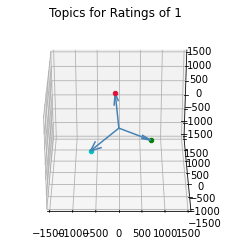

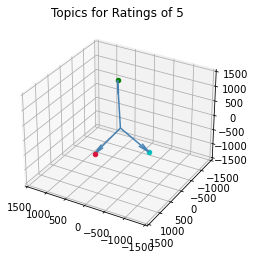

In [191]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.view_init(15, 35)
ax.quiver(0, 0, 0, tsne_3D_list1_topics[:,0], tsne_3D_list1_topics[:,1], tsne_3D_list1_topics[:,2], color='steelblue')

ax.set_xlim([-1500, 1500])
ax.set_ylim([-1500, 1500])
ax.set_zlim([-1500, 1500])
ax.azim = -90
ax.elev = 30

ax.scatter(xs=tsne_3D_list1_topics[0][0], ys=tsne_3D_list1_topics[0][1], zs=tsne_3D_list1_topics[0][2], color='crimson')
ax.scatter(xs=tsne_3D_list1_topics[1][0], ys=tsne_3D_list1_topics[1][1], zs=tsne_3D_list1_topics[1][2], color='g')
ax.scatter(xs=tsne_3D_list1_topics[2][0], ys=tsne_3D_list1_topics[2][1], zs=tsne_3D_list1_topics[2][2], color='c')
plt.title('Topics for Ratings of 1')




fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.view_init(15, 35)
ax.quiver(0, 0, 0, tsne_3D_list5_topics[:,0], tsne_3D_list5_topics[:,1], tsne_3D_list5_topics[:,2], color='steelblue')

ax.set_xlim([-1500, 1500])
ax.set_ylim([-1500, 1500])
ax.set_zlim([-1500, 1500])
ax.azim = 120
ax.elev = 30

ax.scatter(xs=tsne_3D_list5_topics[0][0], ys=tsne_3D_list5_topics[0][1], zs=tsne_3D_list5_topics[0][2], color='crimson')
ax.scatter(xs=tsne_3D_list5_topics[1][0], ys=tsne_3D_list5_topics[1][1], zs=tsne_3D_list5_topics[1][2], color='g')
ax.scatter(xs=tsne_3D_list5_topics[2][0], ys=tsne_3D_list5_topics[2][1], zs=tsne_3D_list5_topics[2][2], color='c')
plt.title('Topics for Ratings of 5')



In [199]:
df_sample_all.star_rating.value_counts()

1    1000
5    1000
Name: star_rating, dtype: int64

In [201]:
df_sample_all.columns


Index(['index', 'marketplace', 'customer_id', 'review_id', 'product_id',
       'product_parent', 'product_title', 'product_category', 'star_rating',
       'helpful_votes', 'total_votes', 'vine', 'verified_purchase',
       'review_headline', 'review_body', 'review_date',
       'titlewave-TP_processed', 'B_sadness', 'B_joy', 'B_love', 'B_anger',
       'B_fear', 'B_surprise', 'RH_sadness', 'RH_joy', 'RH_love', 'RH_anger',
       'RH_fear', 'RH_surprise', 'TWP_sadness', 'TWP_joy', 'TWP_love',
       'TWP_anger', 'TWP_fear', 'TWP_surprise', 'H_B_anger', 'H_B_disgust',
       'H_B_fear', 'H_B_joy', 'H_B_neutral', 'H_B_sadness', 'H_B_surprise',
       'H_RH_anger', 'H_RH_disgust', 'H_RH_fear', 'H_RH_joy', 'H_RH_neutral',
       'H_RH_sadness', 'H_RH_surprise', 'H_TW_anger', 'H_TW_disgust',
       'H_TW_fear', 'H_TW_joy', 'H_TW_neutral', 'H_TW_sadness',
       'H_TW_surprise'],
      dtype='object')

In [204]:
len(df_sample_all['titlewave-TP_processed'])

2000

In [203]:
df_sample_all['titlewave-TP_processed']

0                       Onkyo remote control not working
1      Why does this Antec Portable Wireless Bluetoot...
2                Philips Customer Relations is the WORST
3                       Amzon Netbook charger is a waste
4                         ONKYO has broken twice since I
                             ...                        
995                          How can I get a list of all
996                How to listen for traffic in left ear
997    Yamaha stereo receiver inverted speakers are e...
998                         How to mount a wall-mount in
999                                    AmazonBasics hdmi
Name: titlewave-TP_processed, Length: 2000, dtype: object

In [216]:
df_sample_all['review_body']

0      The remote control stopped working, so I calle...
1      I ordered the Antec Portable Wireless Bluetoot...
2      First of all, this is the first product review...
3      This is a very poor quality charger. First of ...
4      Broke twice since I owned it.  31 days after I...
                             ...                        
995                                           Excellent!
996    This is exactly what I needed for riding my bi...
997    The speakers were purchased for a new Yamaha s...
998    This wall-mount is solid and sturdy, has held ...
999    I was happy to see this hdmi cable offered fro...
Name: review_body, Length: 2000, dtype: object

In [217]:
list5_topics

['earpods satifaction nike daunting excelente college grandfather buen producto bank rapid dissatisfied surrounds alone nearest rigger bien conditions club supporting muy la wwith organ graders proven hoa dance decor scrappy trimmed anchored thumbs manufacturing anchor flexible bros iso designer interferes allman drone engines manejo puestos impresionante hace',
 'equally fast thank delivery anchored satifaction earpods advertised shipping anchor daunting nike grandfather loads bank inadequately crumbly nipple anchors legs misunderstand dissatisfied nearest varying splitters rigger subtle experiences wonderfully poorly college surrounds building adorama fail meant carver circuit against hot rely tester spain decor anchoring tampa twisted eyeing foresee norm',
 'the it to and for good this great of my gift just be is works radio what these easy as expected well that cable little cool looks more splitters on you they nice are wall with we apple have up product can in was got use at fit l

In [234]:
list_words=list(df_sample_all['titlewave-TP_processed'][0] )
print(list_words)



for i  in range(0, len(list_words) ):
       #tokens= word_tokenize(list_words[i])
        tokens=list_words[0].split(" ")
        tokens = [w for w in tokens if w in word2vec_model.key_to_index ]
        list_words[i]=' '.join(tokens)





['Onkyo remote control not working', 'How to use extender in a cabinet']


In [237]:
df_sample_all.iloc[0, :]

index                                                                557765
marketplace                                                              US
customer_id                                                        20513603
review_id                                                    R30K6TEVOZ2SCI
product_id                                                       B00BLGUKDE
product_parent                                                    927786664
product_title             Onkyo TX-NR626 7.2-Channel Network Audio/Video...
product_category                                                Electronics
star_rating                                                               1
helpful_votes                                                             0
total_votes                                                               0
vine                                                                      N
verified_purchase                                                         Y
review_headl

In [240]:
df_sample_all.iloc[1, :]['titlewave-TP_processed']

'Why does this Antec Portable Wireless Bluetooth speaker'

In [252]:
list_words=[df_sample_all.iloc[2, :]['titlewave-TP_processed'] ]
print(list_words)





['Philips Customer Relations is the WORST']
['Philips Customer Relations is the WORST']


In [256]:
from scipy.spatial import distance
from scipy.spatial import minkowski_distance
from scipy.spatial.distance import cosine



dist=[]
def euclid_dist_X_to_eachOfA(one_review_list, list_topics):
    dist=[]
    for ii in range (0, len(list_topics[:,0])):
        dist.append(distance.euclidean(one_review_list, list_topics[ii, :]))
    return dist


dist_cos=[]
def cosine_dist_X_to_eachOfA(one_review_list, list_topics):
    dist_cos=[]
    for ii in range (0, len(list_topics[:,0])):
        # dist_cos.append(cosine_similarity(one_review_list, list_topics[ii, :]))
        dist_cos.append(1-distance.cosine(one_review_list, list_topics[ii, :]))

    return dist_cos



dist_mink=[]
def minkowski_dist_X_to_eachOfA(one_review_list, list_topics):
    dist_mink=[]
    for ii in range (0, len(list_topics[:,0])):
        dist_mink.append(distance.minkowski(one_review_list, list_topics[ii, :]))
    return dist_mink

In [259]:
samplesize= len(df_sample_all['titlewave-TP_processed'])

list_words=[]
dist_review_to_5=[]
list_dist_ave5=[]
dist_review_to_1=[]
list_dist_ave1=[]

mink_dist_review_to_5=[]
list_mink_dist_ave5=[]
mink_ist_review_to_1=[]
list_mink_dist_ave1=[]

cosine_dist_review_to_5=[]
cosine_dist_review_to_1=[]
cosine_list_dist_ave5=[]
cosine_list_dist_ave1=[]

word2vec_model_embeddings_ave_one_review_list=[]

for i in range(0,samplesize ):# 
   
    # list_words=[df_sample_all['review_body'][i]] #<------ titlewave-TP_processed is the SUMMARIZED REVIEW BODY
    list_words=[df_sample_all.iloc[i, :]['titlewave-TP_processed'] ]

    #list_words=check_against_word2vec_model(list_words[0], word2vec_model)
    for i  in range(0, len(list_words) ):
        tokens= word_tokenize(list_words[i])
        tokens = [w for w in tokens if w in word2vec_model.key_to_index ]
        list_words=[' '.join(tokens)]
        #print(list_words)


    
    word2vec_embeddings_one_review=word2vec_model_embeddings.transform(list_words)
    word2vec_model_embeddings_ave_one_review_list.append(word2vec_embeddings_one_review)
    
    
    dist_review_to_5=euclid_dist_X_to_eachOfA(word2vec_embeddings_one_review, word2vec_model_embeddings_ave_list5_topics)
    list_dist_ave5.append(np.mean(dist_review_to_5))
    dist_review_to_1=euclid_dist_X_to_eachOfA(word2vec_embeddings_one_review, word2vec_model_embeddings_ave_list1_topics)
    list_dist_ave1.append(np.mean(dist_review_to_1))
    
    

    
    mink_dist_review_to_5=minkowski_dist_X_to_eachOfA(word2vec_embeddings_one_review, word2vec_model_embeddings_ave_list5_topics)
    list_mink_dist_ave5.append(np.mean(mink_dist_review_to_5))
    mink_ist_review_to_1=minkowski_dist_X_to_eachOfA(word2vec_embeddings_one_review, word2vec_model_embeddings_ave_list1_topics)
    list_mink_dist_ave1.append(np.mean(mink_ist_review_to_1))
    
    
    
    cosine_dist_review_to_5=cosine_dist_X_to_eachOfA(word2vec_embeddings_one_review, word2vec_model_embeddings_ave_list5_topics)
    cosine_list_dist_ave5.append(np.mean(cosine_dist_review_to_5))
    cosine_dist_review_to_1=cosine_dist_X_to_eachOfA(word2vec_embeddings_one_review, word2vec_model_embeddings_ave_list1_topics)
    cosine_list_dist_ave1.append(np.mean(cosine_dist_review_to_1))
    
    
   

/Users/sophie/opt/anaconda3/lib/python3.9/site-packages/scipy/spatial/distance.py:699: RuntimeWarning: invalid value encountered in double_scalars
  dist = 1.0 - uv / np.sqrt(uu * vv)


In [260]:
   

train_100=pd.DataFrame(np.concatenate(word2vec_model_embeddings_ave_one_review_list))
train_100['list_dist_ave1']=list_dist_ave1
train_100['list_dist_ave5']=list_dist_ave5

train_100['list_mink_dist_ave1']=list_mink_dist_ave1
train_100['list_mink_dist_ave5']=list_mink_dist_ave5

train_100['cosine_list_dist_ave5']=cosine_list_dist_ave5
train_100['cosine_list_dist_ave1']=cosine_list_dist_ave1

train_100

,0,1,2,3,4,5,6,7,8,9,...,296,297,298,299,list_dist_ave1,list_dist_ave5,list_mink_dist_ave1,list_mink_dist_ave5,cosine_list_dist_ave5,cosine_list_dist_ave1
0,-0.320020,-0.108640,0.035040,0.056380,-0.021300,0.084160,0.015020,-0.087920,0.079160,0.058600,...,-0.165860,-0.178920,0.043260,0.007720,1.961718,2.017669,1.961718,2.017669,0.548228,0.572098
1,-0.150600,0.157900,0.053875,-0.007975,-0.172213,0.237162,0.210613,0.021462,-0.098288,0.129100,...,0.031588,-0.030800,-0.001713,-0.036362,2.162524,2.200085,2.162524,2.200085,0.488013,0.500956
2,-0.142033,0.190817,0.002367,0.008983,0.211733,0.156367,0.042100,-0.338400,-0.162117,-0.100483,...,0.027683,-0.012683,-0.022883,0.051967,1.906520,1.956993,1.906520,1.956993,0.487741,0.510615
3,-0.064250,0.025733,-0.158633,0.032067,-0.091983,-0.008967,0.019817,0.135567,0.042383,-0.018267,...,0.116300,-0.268200,0.078850,-0.063250,2.024475,2.072902,2.024475,2.072902,0.541340,0.561043
4,-0.140367,-0.035633,-0.001183,-0.082733,0.027917,-0.052150,0.054417,0.021000,-0.181717,0.121750,...,-0.103333,-0.042250,-0.104383,0.053867,1.824270,1.917980,1.824270,1.917980,0.542242,0.586328
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,-0.033788,0.015463,0.015788,-0.060812,-0.028400,0.022612,-0.008100,0.073350,0.156913,-0.042775,...,-0.001013,0.010388,-0.001913,-0.017300,1.355218,1.426624,1.355218,1.426624,0.619170,0.649704
1996,0.052500,-0.036700,0.007925,0.031000,-0.030063,0.094750,-0.089163,0.056800,0.161600,-0.024087,...,0.079225,-0.061225,-0.017600,0.008837,1.444416,1.492888,1.444416,1.492888,0.615497,0.634725
1997,-0.291271,0.092757,-0.051114,0.031300,-0.135714,-0.133929,-0.000329,-0.182557,0.209814,0.118557,...,-0.097543,0.014757,-0.191157,0.123671,2.050744,2.028025,2.050744,2.028025,0.558614,0.539399
1998,-0.066050,0.128717,-0.007083,-0.079200,-0.013067,0.055917,-0.038850,0.027300,0.261533,0.000583,...,0.050550,-0.033083,-0.024783,-0.037417,1.794741,1.780514,1.794741,1.780514,0.579247,0.566908


In [261]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train_100, df_sample_all['star_rating'],  random_state=156)



In [262]:
target_names = ['0 = rating of 1',  '1 = rating of 5'] # 0 = negative, 4 = positive


clf = make_pipeline(StandardScaler(), SVC(gamma='auto', kernel='rbf'))
clf.fit(X_train, y_train)
y_pred=clf.predict(X_test)

clf.score(X_test, y_test)
y_test.value_counts()
print(clf.score(X_test, y_test))

print(classification_report(y_test, y_pred, target_names=target_names, digits=6))

print(confusion_matrix(y_test, y_pred))

/Users/sophie/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(
/Users/sophie/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(
/Users/sophie/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(
/Users/sophie/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised i

0.756
                 precision    recall  f1-score   support

0 = rating of 1   0.784038  0.687243  0.732456       243
1 = rating of 5   0.735192  0.821012  0.775735       257

       accuracy                       0.756000       500
      macro avg   0.759615  0.754127  0.754096       500
   weighted avg   0.758931  0.756000  0.754702       500

[[167  76]
 [ 46 211]]


In [ ]:
#COMBINING THE EMOTIONS, EMBEDDING and TOPIC/Distance/Summarization 

In [263]:
df_sample_all_test

,B_sadness,B_joy,B_love,B_anger,B_fear,B_surprise,RH_sadness,RH_joy,RH_love,RH_anger,...,H_RH_neutral,H_RH_sadness,H_RH_surprise,H_TW_anger,H_TW_disgust,H_TW_fear,H_TW_joy,H_TW_neutral,H_TW_sadness,H_TW_surprise
0,0.021616,0.923181,0.002851,0.033252,0.017946,0.001154,0.036236,0.851451,0.027102,0.051911,...,0.352683,0.429710,0.015872,0.016693,0.017173,0.008433,0.003345,0.225836,0.681197,0.047324
1,0.001975,0.007453,0.001264,0.010322,0.736271,0.242713,0.004461,0.005288,0.000584,0.986504,...,0.288673,0.076862,0.005169,0.017901,0.004540,0.006753,0.004428,0.407758,0.009396,0.549225
2,0.010300,0.937263,0.002398,0.040345,0.008872,0.000821,0.489012,0.015860,0.002303,0.484929,...,0.235000,0.005742,0.389893,0.013400,0.520219,0.015351,0.007285,0.321051,0.008416,0.114279
3,0.990622,0.000755,0.000216,0.006187,0.001977,0.000244,0.010257,0.001060,0.000361,0.986866,...,0.007634,0.019535,0.002382,0.215299,0.288809,0.005130,0.003064,0.067736,0.401438,0.018525
4,0.404692,0.090682,0.003155,0.430420,0.069309,0.001742,0.009622,0.103431,0.004400,0.872440,...,0.499850,0.054250,0.025128,0.047548,0.010333,0.041139,0.004520,0.433568,0.326139,0.136753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.001379,0.994428,0.000726,0.001297,0.000908,0.001262,0.020340,0.844914,0.008725,0.092320,...,0.874900,0.009004,0.035351,0.035207,0.014538,0.007285,0.002207,0.372287,0.090918,0.477556
996,0.000974,0.996148,0.000584,0.001648,0.000415,0.000230,0.000370,0.997576,0.000438,0.000292,...,0.094582,0.010198,0.406256,0.014728,0.025534,0.025787,0.002114,0.873229,0.019082,0.039525
997,0.000586,0.997544,0.000354,0.000790,0.000338,0.000387,0.000914,0.996471,0.000548,0.000882,...,0.425707,0.017549,0.018133,0.006754,0.004399,0.001928,0.505267,0.317498,0.011282,0.152872
998,0.000804,0.996553,0.000537,0.001239,0.000590,0.000277,0.021626,0.219310,0.003925,0.737875,...,0.198050,0.004890,0.425935,0.021175,0.011438,0.050058,0.004362,0.808873,0.007262,0.096833


In [267]:
df_sample_all_test22=df_sample_all_test
df_sample_all_test22=df_sample_all_test22.join(train_100)
df_sample_all_test22


,B_sadness,B_joy,B_love,B_anger,B_fear,B_surprise,RH_sadness,RH_joy,RH_love,RH_anger,...,296,297,298,299,list_dist_ave1,list_dist_ave5,list_mink_dist_ave1,list_mink_dist_ave5,cosine_list_dist_ave5,cosine_list_dist_ave1
0,0.021616,0.923181,0.002851,0.033252,0.017946,0.001154,0.036236,0.851451,0.027102,0.051911,...,-0.165860,-0.178920,0.043260,0.007720,1.961718,2.017669,1.961718,2.017669,0.548228,0.572098
0,0.000514,0.998012,0.000332,0.000532,0.000308,0.000302,0.006833,0.972215,0.001448,0.013017,...,-0.165860,-0.178920,0.043260,0.007720,1.961718,2.017669,1.961718,2.017669,0.548228,0.572098
1,0.001975,0.007453,0.001264,0.010322,0.736271,0.242713,0.004461,0.005288,0.000584,0.986504,...,0.031588,-0.030800,-0.001713,-0.036362,2.162524,2.200085,2.162524,2.200085,0.488013,0.500956
1,0.000662,0.996861,0.000545,0.000805,0.000358,0.000769,0.000604,0.997302,0.000409,0.000634,...,0.031588,-0.030800,-0.001713,-0.036362,2.162524,2.200085,2.162524,2.200085,0.488013,0.500956
2,0.010300,0.937263,0.002398,0.040345,0.008872,0.000821,0.489012,0.015860,0.002303,0.484929,...,0.027683,-0.012683,-0.022883,0.051967,1.906520,1.956993,1.906520,1.956993,0.487741,0.510615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997,0.000586,0.997544,0.000354,0.000790,0.000338,0.000387,0.000914,0.996471,0.000548,0.000882,...,-0.079300,-0.091357,-0.068071,-0.027900,1.671907,1.698914,1.671907,1.698914,0.534375,0.542495
998,0.004464,0.008689,0.000335,0.022952,0.961210,0.002350,0.013769,0.014041,0.000998,0.414798,...,0.042020,0.050600,0.114820,-0.053940,2.121249,2.146059,2.121249,2.146059,0.521726,0.529214
998,0.000804,0.996553,0.000537,0.001239,0.000590,0.000277,0.021626,0.219310,0.003925,0.737875,...,0.042020,0.050600,0.114820,-0.053940,2.121249,2.146059,2.121249,2.146059,0.521726,0.529214
999,0.991790,0.001838,0.000330,0.005175,0.000561,0.000305,0.017401,0.001498,0.000524,0.961722,...,0.006675,-0.112500,-0.079375,0.101125,1.327575,1.341282,1.327575,1.341282,0.667160,0.667084


In [269]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_sample_all_test22, df_sample_all['star_rating'],  random_state=156)







In [275]:

#clf = SVC( C=1000, gamma= 0.001, kernel= 'rbf' )


clf = make_pipeline(StandardScaler(), SVC( C=1000, gamma= 0.001, kernel= 'rbf'))
clf.fit(X_train, y_train)
y_pred=clf.predict(X_test)

clf.score(X_test, y_test)
y_test.value_counts()
print(clf.score(X_test, y_test))

print(classification_report(y_test, y_pred, target_names=target_names, digits=6))

print(confusion_matrix(y_test, y_pred))


/Users/sophie/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(
/Users/sophie/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(
/Users/sophie/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(
/Users/sophie/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised i

0.786
                 precision    recall  f1-score   support

0 = rating of 1   0.776423  0.786008  0.781186       243
1 = rating of 5   0.795276  0.785992  0.790607       257

       accuracy                       0.786000       500
      macro avg   0.785849  0.786000  0.785896       500
   weighted avg   0.786113  0.786000  0.786028       500

[[191  52]
 [ 55 202]]


/Users/sophie/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(


In [ ]:
## Going back to the emotions + selecting a larger sample size........   TO BE CONTINUED AFTER 4/28

In [279]:
df.star_rating.value_counts()

5    1779304
4     536398
1     357800
3     238378
2     179025
Name: star_rating, dtype: int64

In [284]:
N=2000 #
df_sample1=df.loc[df['star_rating'] == 1].sample(N, replace=False, random_state=135)
df_sample5=df.loc[df['star_rating'] == 5].sample(N, replace=False, random_state=135)


df_sample1.reset_index(inplace=True)
df_sample5.reset_index(inplace=True)


##fkt
df_sample1['titlewave-TP_processed']=df_sample1['product_title']
df_sample5['titlewave-TP_processed']=df_sample5['product_title']








In [ ]:
df_sample1=emotion_distilbert(df_sample1)

df_sample5=emotion_distilbert(df_sample5)


df_sample1=emotion_roberta(df_sample1)
df_sample5=emotion_roberta(df_sample5)


df_sample_all=df_sample1
df_sample_all=df_sample_all.append(df_sample5)


df_sample_all.star_rating.value_counts()

In [ ]:

df_sample_all_test=df_sample_all[['B_sadness', 'B_joy', 'B_love', 'B_anger',
       'B_fear', 'B_surprise', 'RH_sadness', 'RH_joy', 'RH_love', 'RH_anger',
       'RH_fear', 'RH_surprise', 'TWP_sadness', 'TWP_joy', 'TWP_love',
       'TWP_anger', 'TWP_fear', 'TWP_surprise', 'H_B_anger', 'H_B_disgust',
       'H_B_fear', 'H_B_joy', 'H_B_neutral', 'H_B_sadness', 'H_B_surprise',
       'H_RH_anger', 'H_RH_disgust', 'H_RH_fear', 'H_RH_joy', 'H_RH_neutral',
       'H_RH_sadness', 'H_RH_surprise', 'H_TW_anger', 'H_TW_disgust',
       'H_TW_fear', 'H_TW_joy', 'H_TW_neutral', 'H_TW_sadness',
       'H_TW_surprise']]






from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_sample_all_test, df_sample_all['star_rating'],  random_state=156)


#'C': 1000, 'gamma': 0.001, 'kernel': 'rbf'}
clf = make_pipeline(StandardScaler(), SVC( C=1000, gamma= 0.001, kernel= 'rbf'))
clf.fit(X_train, y_train)
y_pred=clf.predict(X_test)

clf.score(X_test, y_test)
y_test.value_counts()
print(clf.score(X_test, y_test))

print(classification_report(y_test, y_pred, target_names=target_names, digits=6))

print(confusion_matrix(y_test, y_pred))
